# Heart Disease Prediction

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( accuracy_score , precision_score,
    recall_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc )


# Importing the data

In [149]:
# Here we stored the  Heart Disease UCI original data in the variable named "original_data"
original_data=pd.read_csv('Heart.csv')

# Creating working copy
data = original_data.copy()
original_data.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


# Analysing the Data

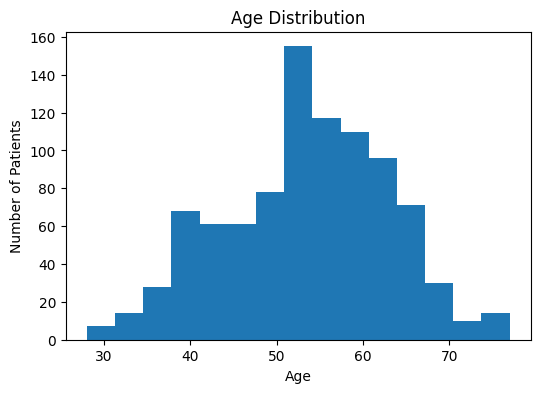

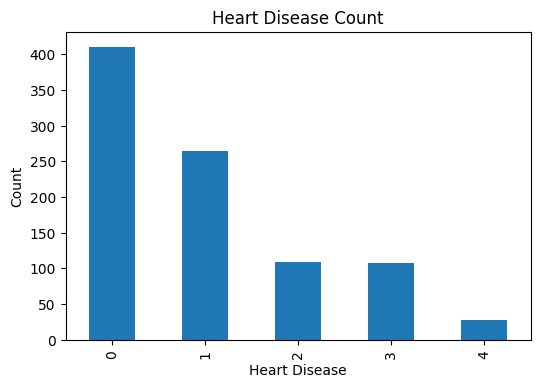

In [150]:
plt.figure(figsize=(6,4))
plt.hist(original_data['age'], bins=15)                  # I used the histogram that will shows how patient ages are distributed.
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")
plt.show()


plt.figure(figsize=(6,4))
original_data['num'].value_counts().plot(kind='bar')     # This is a Comparison Plot that will Shows how many patients have disease and how many do not.
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Heart Disease Count")
plt.show()


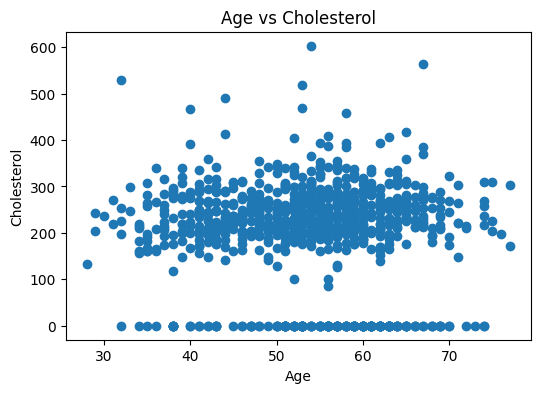

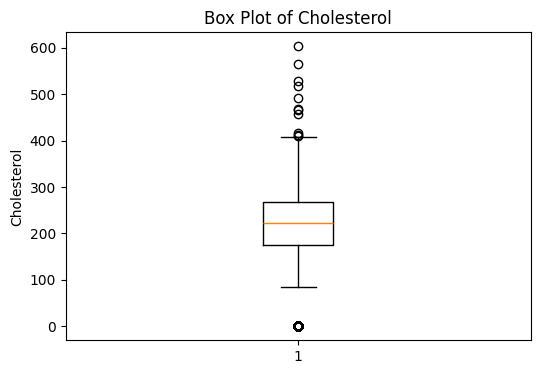

In [151]:
plt.figure(figsize=(6,4))
plt.scatter(original_data['age'], data['chol'])          # This is a Scatter plot that shows the relationship between two features "age" and "chol"
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("Age vs Cholesterol")
plt.show()


plt.figure(figsize=(6,4))
plt.boxplot(original_data['chol'].dropna())              # I used a Box Plot for chol (cholesterol) because cholesterol values often contain
plt.ylabel("Cholesterol")                                # very high values ,very low values ,possible outliers
plt.title("Box Plot of Cholesterol")                     # A box plot is very good for detecting those values and outliers.
plt.show()


# Checking for the null values

In [152]:
original_data.isnull()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
916,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False
917,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
918,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False


In [153]:
""" So there are null values in the dataset and if the null values are not removed,
they may affect model performance and reduce the performance of the model"""

original_data.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


# Cleaning the data

In [154]:
""" As there are null values in the dataset which will affect the  performance
of the model . So, we are removing the null values from the dataset by filling
them using the mean and mode """

""" We used the mean to fill null values in numerical columns because mean
represents the average value of the feature and helps preserve the overall
distribution of the data. """

data['trestbps']=data['trestbps'].fillna(data['trestbps'].mean())
data['chol']=data['chol'].fillna(data['chol'].mean())
data['thalch']=data['thalch'].fillna(data['thalch'].mean())
data['oldpeak']=data['oldpeak'].fillna(data['oldpeak'].mean())

""" We used the mode to fill null values in  these categorical columns because
 mode represents the most frequently occurring category in the dataset"""

data['fbs']=data['fbs'].fillna(data['fbs'].mode()[0])
data['fbs'] = data['fbs'].astype(int)
data['exang']=data['exang'].fillna(data['exang'].mode()[0])
data['exang'] = data['exang'].astype(int)
data['restecg']=data['restecg'].fillna(data['restecg'].mode()[0])
data['slope']=data['slope'].fillna(data['slope'].mode()[0])
data['thal']=data['thal'].fillna(data['thal'].mode()[0])

""" We did Encoding to convert categorical/text data into numerical format
because our machine learning models cannot process string values directly. """

data=pd.get_dummies(data,columns=['sex','cp','restecg','slope','thal'],
                    drop_first=True,dtype='int')

""" We droped the "ca" column because more than 50% of the data was missing in
that column"""

data=data.drop('ca',axis=1)


/tmp/ipykernel_8163/2515900571.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['fbs']=data['fbs'].fillna(data['fbs'].mode()[0])
/tmp/ipykernel_8163/2515900571.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['exang']=data['exang'].fillna(data['exang'].mode()[0])


In [155]:
# Printing the Cleaned and analysed data
data.head(10)

,id,age,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1,63,Cleveland,145.0,233.0,1,150.0,0,2.3,0,1,0,0,1,0,0,0,0,0,0
1,2,67,Cleveland,160.0,286.0,0,108.0,1,1.5,2,1,0,0,0,0,0,1,0,1,0
2,3,67,Cleveland,120.0,229.0,0,129.0,1,2.6,1,1,0,0,0,0,0,1,0,0,1
3,4,37,Cleveland,130.0,250.0,0,187.0,0,3.5,0,1,0,1,0,1,0,0,0,1,0
4,5,41,Cleveland,130.0,204.0,0,172.0,0,1.4,0,0,1,0,0,0,0,0,1,1,0
5,6,56,Cleveland,120.0,236.0,0,178.0,0,0.8,0,1,1,0,0,1,0,0,1,1,0
6,7,62,Cleveland,140.0,268.0,0,160.0,0,3.6,3,0,0,0,0,0,0,0,0,1,0
7,8,57,Cleveland,120.0,354.0,0,163.0,1,0.6,0,0,0,0,0,1,0,0,1,1,0
8,9,63,Cleveland,130.0,254.0,0,147.0,0,1.4,2,1,0,0,0,0,0,1,0,0,1
9,10,53,Cleveland,140.0,203.0,1,155.0,1,3.1,1,1,0,0,0,0,0,0,0,0,1


# Assigning the features and targets

In [156]:
X=data.drop(['id','dataset','num'],axis=1)       # Assigning all the features to X except ('id','dataset','num')

""" The target column "num" was converted into binary classes to simplify the
prediction problem into heart disease and no heart disease classification."""

data['num'] = (data['num'] > 0).astype(int)
Y=data['num']                                   # Assigning the target variable to Y

# Data Splitting and Feature Scaling

In [157]:
""" In Data Splitting the dataset was split into four parts: X_train, X_test,
 y_train, and y_test using train_test_split()."""

X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

"""I did Feature scaling using StandardScaler to the standardize numerical features
so that all features contribute equally to the Logistic Regression model.Scaling
transforms the data to have a mean of 0 and a standard deviation of 1."""


num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
scaler = StandardScaler()          # Creating scaler
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
print(X_train.head())


          age  trestbps      chol  fbs    thalch  exang   oldpeak  sex_Male  \
880  0.902413  0.023339 -0.255361    0 -0.688840      1  1.969233         1   
457  0.034776  0.980993  0.012122    0 -0.609629      0 -0.818785         1   
797 -0.290587  0.023339  1.296446    0  0.006064      0 -0.002093         1   
25  -0.399042 -0.626924  0.194571    0  0.816167      0  0.668158         0   
84  -0.182133 -0.626924  1.167894    0  1.370643      0 -0.632917         1   

     cp_atypical angina  cp_non-anginal  cp_typical angina  restecg_normal  \
880                   0               0                  0               0   
457                   0               1                  0               1   
797                   0               1                  0               1   
25                    0               1                  0               1   
84                    1               0                  0               1   

     restecg_st-t abnormality  slope_flat  slope_upslopi

# Training the Logistic Regression Model and Making Predictions

In [158]:
""" We trained the Logistic Regression model using the training dataset (X_train and y_train).
During training, the model learned the relationship between patient features
and the presence of heart disease. """

model=LogisticRegression()
model.fit(X_train,y_train)

""" After the training, predictions were made on the testing dataset (X_test) using
the trained model.  """

prediction=model.predict(X_test)
print(prediction)

[0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0 0 0 1 1 0 1 1 1 1 1 1 0 1 0 0 0 0 1 0 1 0
 0 1 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 1 0
 1 0 0 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 1 1 1 1 0 1 1 0 1 0 1
 1 1 0 0 0 1 0 1 0 1 1 0 1 1 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1
 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 1]


# Model Evaluation Using Accuracy, Precision, and Recall

In [159]:
"""Accuracy measures how many predictions made by the model were
 correct out of all predictions."""

accuracy = accuracy_score(y_test, prediction)   # Accuracy
print("Accuracy :", accuracy)

""" Precision measures how many patients predicted as having heart
 disease actually had heart disease. """

precision = precision_score(y_test, prediction) # Precision
print("Precision:", precision)

""" Recall measures how many actual heart disease patients were
correctly identified by the model. """

recall = recall_score(y_test, prediction)       # Recall
print("Recall:", recall)

Accuracy : 0.8152173913043478
Precision: 0.8504672897196262
Recall: 0.8348623853211009


# Confusion Matrix and ROC Curve Visualization

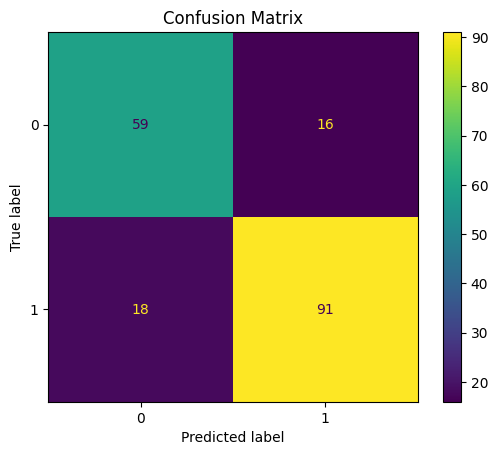

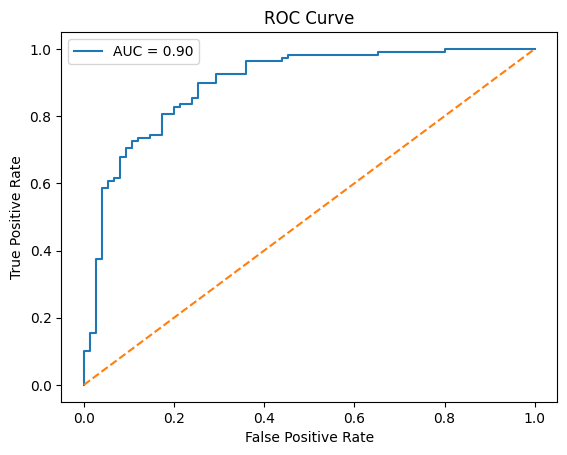

In [160]:
""" We used the confusion matrix to visualize the performance of the our classification
model by comparing actual and predicted values and showing true positives,
true negatives, false positives, and false negatives."""

matrix = confusion_matrix(y_test, prediction)      # Confusion Matrix
show = ConfusionMatrixDisplay(confusion_matrix=matrix)
show.plot()
plt.title("Confusion Matrix")
plt.show()

""" We used the ROC curve to evaluate the classification performance of our model
by plotting the True Positive Rate against the False Positive Rate at various threshold
levels. The AUC score summarizes the overall discriminative ability of the model."""


y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)                             # ROC Curve
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()